In [23]:
import kagglehub
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
from models.mlp import MLP
import util


In [24]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


In [25]:
path = kagglehub.dataset_download("muhammadrehan00/chest-xray-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/madsfjeldberg/.cache/kagglehub/datasets/muhammadrehan00/chest-xray-dataset/versions/1


Output path ./normalized_images already exists. Skipping normalization.


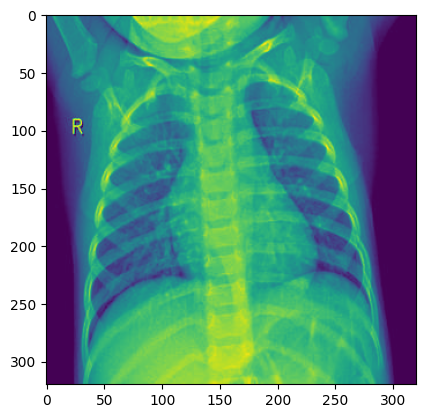

In [26]:
# Normalize and save images locally to ./normalized_images
util.normalize_and_save_images(path, output_path="./normalized_images")

plt.imshow(Image.open("./normalized_images/train/NORMAL/normal-929.jpg"))

# Set path to the normalized images for further processing
path = "./normalized_images"

In [27]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Since images are already normalized, just convert to tensor
# IMPORTANT: Add proper normalization - normalize to [0, 1] range with ImageNet stats
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    # Normalize with ImageNet stats (works even for grayscale -> 3 channels)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# ImageFolder reads subfolders as class labels automatically
train_dataset = datasets.ImageFolder("normalized_images/train", transform=transform)
val_dataset   = datasets.ImageFolder("normalized_images/val",   transform=transform)
test_dataset  = datasets.ImageFolder("normalized_images/test",  transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Sanity check
print(train_dataset.classes)          # should print ['NORMAL', 'PNEUMONIA']
print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

['NORMAL', 'PNEUMONIA']
Train: 11937
Val:   1470
Test:  1505


In [28]:
import time
from torch.utils.data import Subset
from models.mlp import train_epoch, evaluate

# Reload the module to pick up any changes
import importlib
import sys
if 'models.mlp' in sys.modules:
    importlib.reload(sys.modules['models.mlp'])
    from models.mlp import train_epoch, evaluate

# --- Setup ---
clf_name = "MLP"
num_epochs = 10
lr = 1e-3
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()  # Numerically stable: fuses sigmoid + BCE internally

train_subset_size = min(10000, len(train_dataset))
train_subset = Subset(train_dataset, range(train_subset_size))
train_subset_loader = DataLoader(train_subset, batch_size=32, shuffle=False)

def binary_accuracy(y_prob, y_true, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y_true.astype(int)
    return (y_pred == y_true).mean()

def compute_val_loss(model, loader, criterion):
    """Compute average validation loss over all batches"""
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(model.net[0].weight.device), labels.to(model.net[0].weight.device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches if num_batches > 0 else 0

print(f"-- {clf_name}")
print(f"-- Epochs: {num_epochs}")
print(f"-- Learning rate: {lr}")

train_losses = []
val_losses = []

t0 = time.time()
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    train_losses.append(train_loss)

    val_loss = compute_val_loss(model, val_loader, criterion)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

t1 = time.time()
print(f"\tTraining time:\t\t{t1 - t0:3.3f}s")

train_preds, train_labels = evaluate(model, train_subset_loader)
score_train = binary_accuracy(train_preds, train_labels)
t2 = time.time()
print(f"\tPrediction time(train):\t{t2 - t1:3.3f}s")

test_preds, test_labels = evaluate(model, test_loader)
score_test = binary_accuracy(test_preds, test_labels)
t3 = time.time()
print(f"\tPrediction time(val):\t{t3 - t2:3.3f}s")
print(f"\tScore Train: {score_train:.3f}\tScore Test: {score_test:.3f}")

-- MLP
-- Epochs: 10
-- Learning rate: 0.001
Epoch 1/10 - Train Loss: 0.9880, Val Loss: 0.2319
Epoch 2/10 - Train Loss: 0.2888, Val Loss: 0.3044
Epoch 3/10 - Train Loss: 0.2829, Val Loss: 0.2908
Epoch 4/10 - Train Loss: 0.2600, Val Loss: 0.2263
Epoch 5/10 - Train Loss: 0.2926, Val Loss: 0.2697
Epoch 6/10 - Train Loss: 0.2379, Val Loss: 0.2190
Epoch 7/10 - Train Loss: 0.2272, Val Loss: 0.2102
Epoch 8/10 - Train Loss: 0.2121, Val Loss: 0.2191
Epoch 9/10 - Train Loss: 0.2345, Val Loss: 0.2244
Epoch 10/10 - Train Loss: 0.2291, Val Loss: 0.2138
	Training time:		404.736s
	Prediction time(train):	18.491s
	Prediction time(val):	2.773s
	Score Train: 0.875	Score Test: 0.884


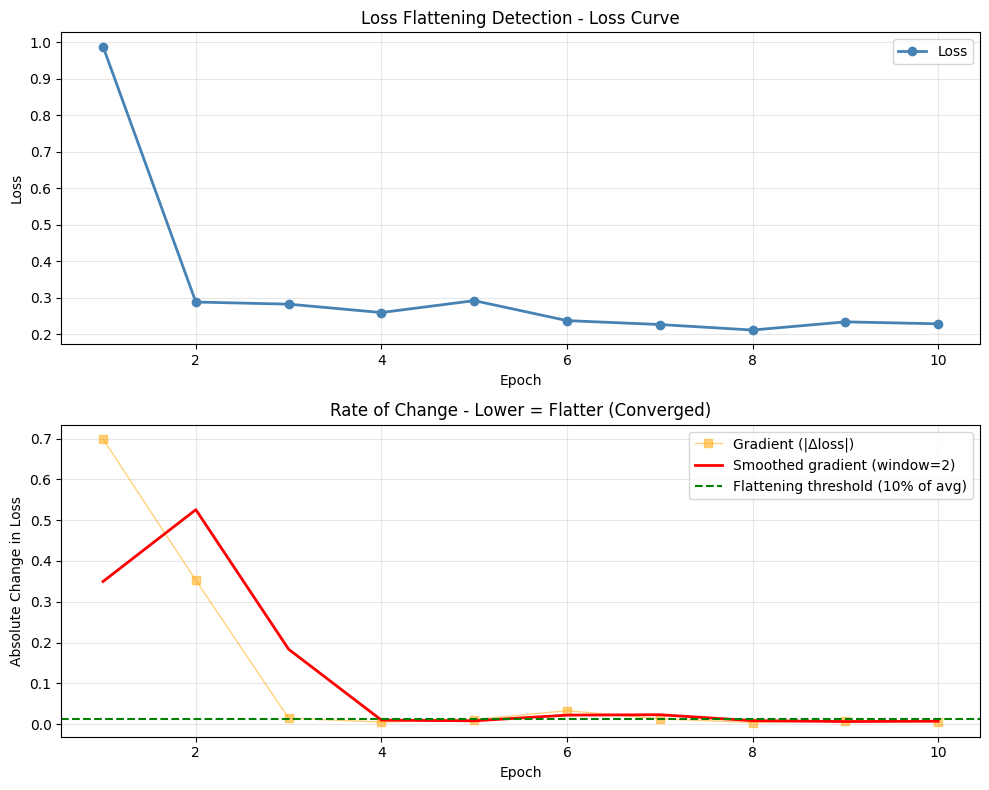


✓ Loss appears to flatten starting around epoch 4


In [29]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, window_size=2)

In [30]:
# Diagnostic: Check data and model output ranges
print("=== Data & Model Diagnostics ===")

# Check one batch of training data
batch_images, batch_labels = next(iter(train_loader))
print(f"Image shape: {batch_images.shape}")
print(f"Image min: {batch_images.min():.4f}, max: {batch_images.max():.4f}, mean: {batch_images.mean():.4f}")
print(f"Labels unique values: {batch_labels.unique()}")

# Check model output on this batch
with torch.no_grad():
    batch_images_device = batch_images.to(device)
    model_output = model(batch_images_device)
    print(f"\nModel output shape: {model_output.shape}")
    print(f"Model output range: [{model_output.min():.6f}, {model_output.max():.6f}]")
    print(f"Model output mean: {model_output.mean():.6f}")
    print(f"Model output std: {model_output.std():.6f}")
    
    # Check if model is predicting mostly 0.5 (random)
    near_half = (model_output > 0.45) & (model_output < 0.55)
    print(f"Predictions near 0.5 (random): {near_half.float().mean():.1%}")

# Check if gradients are flowing
print("\n=== Gradient Check ===")
test_batch_img, test_batch_lbl = next(iter(train_loader))
test_batch_img = test_batch_img.to(device)
test_batch_lbl = test_batch_lbl.float().unsqueeze(1).to(device)

outputs = model(test_batch_img)
loss = criterion(outputs, test_batch_lbl)
loss.backward()

for name, param in list(model.named_parameters())[:3]:
    if param.grad is not None:
        print(f"{name}: grad mean={param.grad.mean().item():.6e}, grad std={param.grad.std().item():.6e}")
    else:
        print(f"{name}: NO GRADIENT")

=== Data & Model Diagnostics ===
Image shape: torch.Size([32, 3, 224, 224])
Image min: -2.1179, max: 2.6400, mean: 0.1882
Labels unique values: tensor([0, 1])

Model output shape: torch.Size([32, 1])
Model output range: [-101.456848, 22.463659]
Model output mean: -16.353697
Model output std: 34.849991
Predictions near 0.5 (random): 0.0%

=== Gradient Check ===
net.0.weight: grad mean=-1.397180e-07, grad std=2.881762e-06
net.0.bias: grad mean=-1.941759e-07, grad std=3.230191e-06
net.3.weight: grad mean=-1.318855e-04, grad std=3.410212e-03
